CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [4]:
# TODO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU 사용 여부 확인
model = myCNN().to(device)  # 모델을 지정한 장치로 이동
criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 문제이므로 CrossEntropyLoss 사용
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 최적화 알고리즘 사용

모델 학습 ✅

In [5]:
# TODO
def train_model():
    train_losses.clear()
    for epoch in range(n_epochs):
        model.train()  # 모델을 학습 모드로 설정
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()  # 그래디언트 초기화
            output = model(images)  # 모델 예측
            loss = criterion(output, labels)  # 손실 계산
            loss.backward()  # 역전파 수행
            optimizer.step()  # 가중치 업데이트
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))  # 평균 손실 저장

        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_losses[-1]:.4f}")

모델 평가 ✅

In [6]:
# TODO
def evaluate_model():
    model.eval()  # 모델을 평가 모드로 설정
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # 평가 과정에서는 그래디언트 계산 X
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            test_loss += criterion(output, labels).item()
            _, predicted = torch.max(output, 1)  # 가장 높은 확률을 가진 클래스로 예측
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))  # 평균 테스트 손실 저장
    test_accuracies.append(100 * correct / total)  # 정확도 저장

    print(f"Test Loss: {test_losses[-1]:.4f}, Test Accuracy: {test_accuracies[-1]:.2f}%")

10회 반복 시행 ✅

In [8]:
# TODO
n_epochs = 1

def run_experiment():
    global train_losses, test_losses, test_accuracies
    train_losses = []
    test_losses = []
    test_accuracies = []

    for i in range(10):
        print(f"\n Experiment {i+1}/10")
        train_model()
        evaluate_model()

run_experiment()


 Experiment 1/10
Epoch 1/1, Train Loss: 0.1285
Test Loss: 0.0454, Test Accuracy: 98.62%

 Experiment 2/10
Epoch 1/1, Train Loss: 0.0396
Test Loss: 0.0278, Test Accuracy: 99.18%

 Experiment 3/10
Epoch 1/1, Train Loss: 0.0270
Test Loss: 0.0332, Test Accuracy: 98.99%

 Experiment 4/10
Epoch 1/1, Train Loss: 0.0205
Test Loss: 0.0277, Test Accuracy: 99.19%

 Experiment 5/10
Epoch 1/1, Train Loss: 0.0160
Test Loss: 0.0324, Test Accuracy: 99.02%

 Experiment 6/10
Epoch 1/1, Train Loss: 0.0140
Test Loss: 0.0301, Test Accuracy: 99.24%

 Experiment 7/10
Epoch 1/1, Train Loss: 0.0131
Test Loss: 0.0383, Test Accuracy: 98.88%

 Experiment 8/10
Epoch 1/1, Train Loss: 0.0106
Test Loss: 0.0294, Test Accuracy: 99.13%

 Experiment 9/10
Epoch 1/1, Train Loss: 0.0097
Test Loss: 0.0345, Test Accuracy: 99.15%

 Experiment 10/10
Epoch 1/1, Train Loss: 0.0081
Test Loss: 0.0363, Test Accuracy: 99.10%


결과 시각화

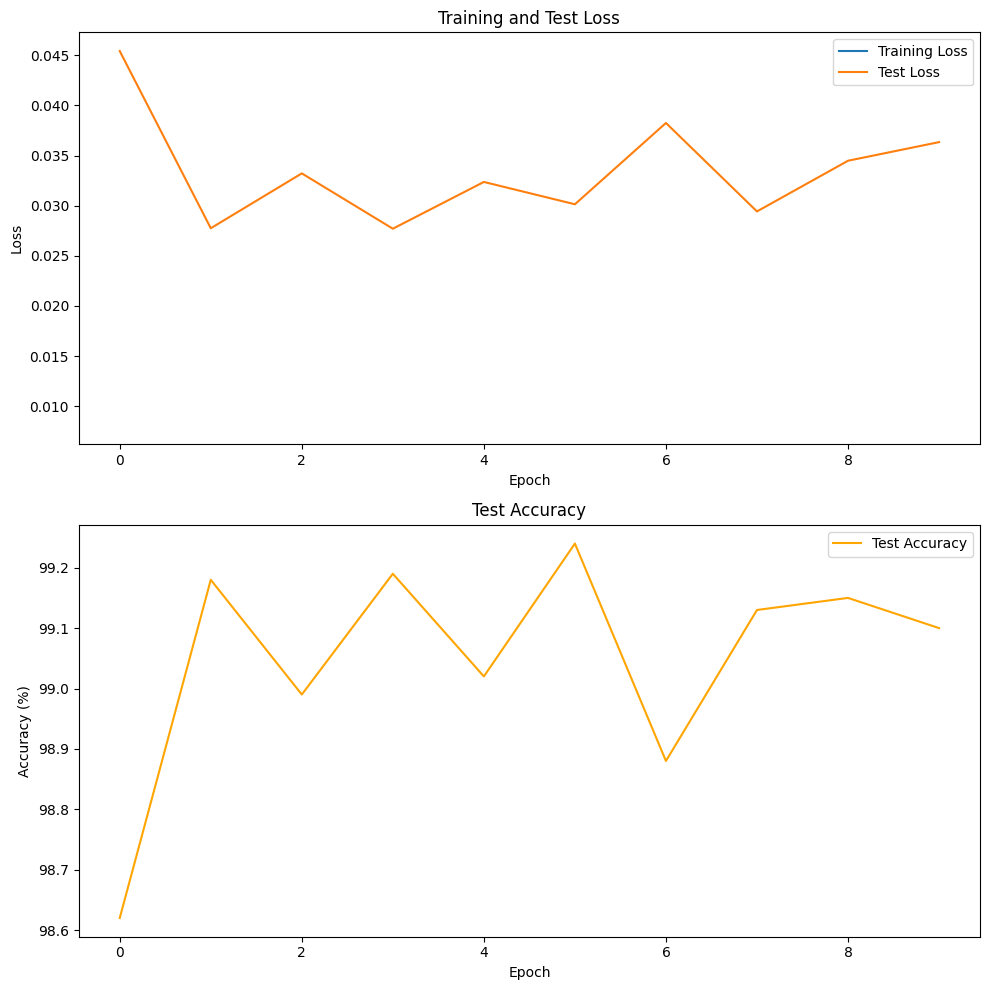

In [9]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()